# 부산광역시 쓰레기 배출량 예측 pt.9

### : `재활용/종량제` 값 추이 확인

<br>

## 00. 기본 설정 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact

# 경고 메시지는 출력 X
import warnings
warnings.filterwarnings("ignore")

In [3]:
# 한글 font 설정

import platform
import matplotlib.font_manager as fm

#matplotlib 패키지 한글 깨짐 처리
#------------------------------------------------------------------------------------
# 운영체제별 한글 폰트 설정

if platform.system() == 'Darwin':           # Mac 환경 폰트 설정
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':        # Windows 환경 폰트 설정
    plt.rc('font', family='Malgun Gothic')
    
plt.rcParams['axes.unicode_minus'] = False #한글 폰트 사용시 마이너스 폰트 깨짐 해결

In [4]:
# 글씨 선명하게 출력하는 설정

from IPython.display import set_matplotlib_formats
set_matplotlib_formats("retina")

<Axes: title={'center': '한글타이틀'}>

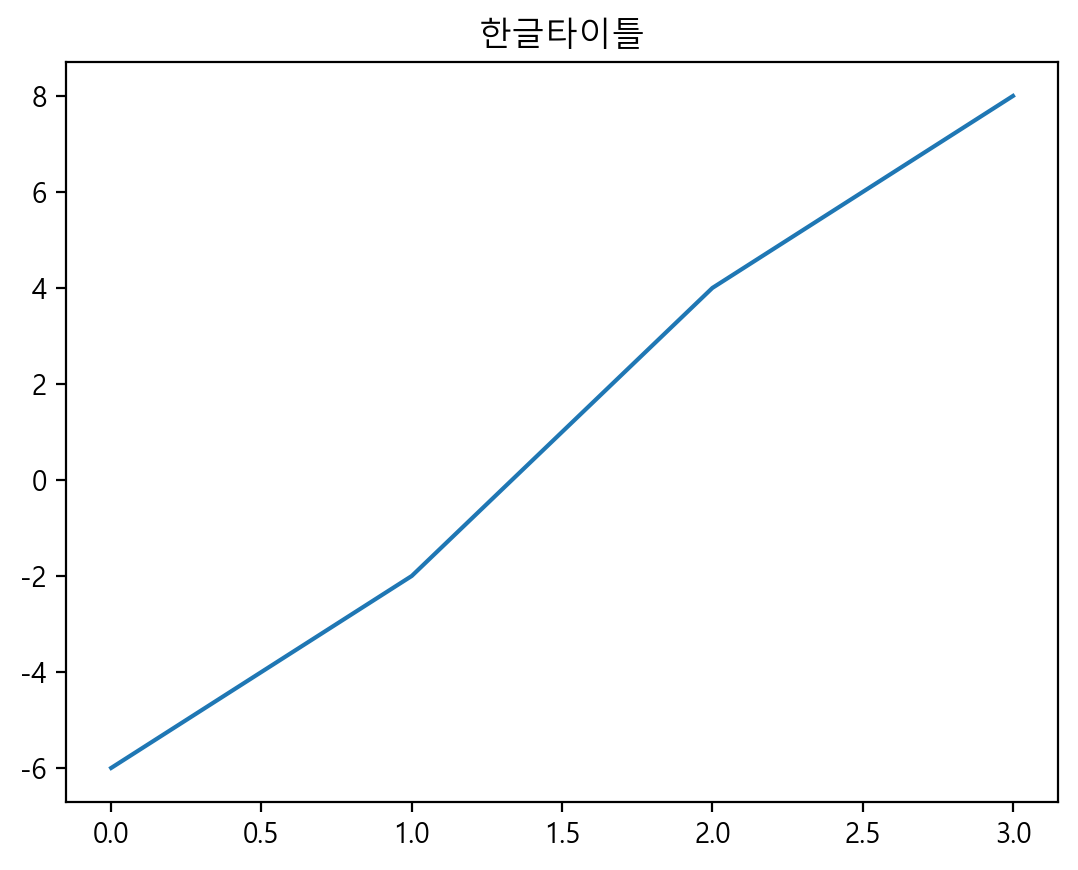

In [5]:
# 한글폰트와 마이너스 폰트 설정 확인
pd.Series([-6, -2, 4, 8]).plot(title="한글타이틀")

<br><br>

---
## 01. 데이터 불러오기

In [14]:
model = pd.read_csv("data/최종_모델학습용.csv", encoding="cp949")
print(f"데이터프레임 shape: {model.shape}")
model.head(1)

데이터프레임 shape: (590, 25)


,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,...,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도_2019,연도_2020,연도_2021,연도_2022,연도_2023
0,강원_고성군,2863.8,강원,고성군,15291,27274,0.6845,0.2642,0.0116,0.0115,...,0.386303,0.365099,0.144122,0.074742,0.029734,0,0,0,1,0


In [15]:
# 원-핫 인코딩된 연도 열들
year_columns = ['연도_2019', '연도_2020', '연도_2021', '연도_2022', '연도_2023']

# 연도 열에서 실제 연도 추출
model['연도'] = model[year_columns].idxmax(axis=1).str.extract('(\d+)').astype(int)
model.head(1)

,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,...,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도_2019,연도_2020,연도_2021,연도_2022,연도_2023,연도
0,강원_고성군,2863.8,강원,고성군,15291,27274,0.6845,0.2642,0.0116,0.0115,...,0.365099,0.144122,0.074742,0.029734,0,0,0,1,0,2022


In [7]:
df = pd.read_csv("data/폐기물데이터_행정구역변경_2.csv", encoding="cp949")
print(f"데이터프레임 shape: {df.shape}")
df.head(3)

데이터프레임 shape: (42365, 12)


,행정구역,시도,시군구,폐기물_종류,폐기물_종류1,폐기물_종류2,재활용,소각,매립,기타,발생량,연도
0,서울_종로구,서울,종로구,종량제방식 등 혼합배출,가연성,폐지류,0.0,9125.0,4672.0,0.0,13797.0,2019
1,서울_종로구,서울,종로구,종량제방식 등 혼합배출,가연성,폐합성수지류,0.0,5365.5,2737.5,0.0,8103.0,2019
2,서울_종로구,서울,종로구,종량제방식 등 혼합배출,가연성,폐고무류,0.0,182.5,73.0,0.0,255.5,2019


In [9]:
# 폐기물_종류 == "종량제방식 등 혼합배출"에 해당하는 행만 남기기
df_filtered = df[df['폐기물_종류'] == "종량제방식 등 혼합배출"].reset_index(drop=True)
print(f"데이터프레임 shape: {df_filtered.shape}")
df_filtered.head()

데이터프레임 shape: (17175, 12)


,행정구역,시도,시군구,폐기물_종류,폐기물_종류1,폐기물_종류2,재활용,소각,매립,기타,발생량,연도
0,서울_종로구,서울,종로구,종량제방식 등 혼합배출,가연성,폐지류,0.0,9125.0,4672.0,0.0,13797.0,2019
1,서울_종로구,서울,종로구,종량제방식 등 혼합배출,가연성,폐합성수지류,0.0,5365.5,2737.5,0.0,8103.0,2019
2,서울_종로구,서울,종로구,종량제방식 등 혼합배출,가연성,폐고무류,0.0,182.5,73.0,0.0,255.5,2019
3,서울_종로구,서울,종로구,종량제방식 등 혼합배출,가연성,폐섬유류,0.0,511.0,255.5,0.0,766.5,2019
4,서울_종로구,서울,종로구,종량제방식 등 혼합배출,가연성,음식물류 폐기물,0.0,693.5,365.0,0.0,1058.5,2019


In [10]:
# 행정구역-연도별 '재활용', '소각', '매립', '기타', '발생량'의 합을 가진 데이터프레임 만들기
grouped_df = df.groupby(['행정구역', '연도'])[['재활용', '소각', '매립', '기타', '발생량']].sum().reset_index()
print(f"데이터프레임 shape: {grouped_df.shape}")
grouped_df.head()

데이터프레임 shape: (1145, 7)


,행정구역,연도,재활용,소각,매립,기타,발생량
0,강원_강릉시,2019,48508.5,1971.0,40369.0,0.0,90848.5
1,강원_강릉시,2020,34581.8,1520.8,43365.9,0.0,79468.5
2,강원_강릉시,2021,35932.1,1266.6,45614.7,0.0,82813.4
3,강원_강릉시,2022,29747.6,606.0,43184.2,0.0,73537.8
4,강원_강릉시,2023,28139.3,35225.7,3660.2,2132.9,69158.1


In [16]:
# 종량제 중 재활용이 있는 지역만 (모델학습에 사용된 지역만 남기기)
filter_keys = model[['행정구역', '연도']].drop_duplicates()

# inner join으로 해당 조합만 필터링
filtered_grouped = pd.merge(grouped_df, filter_keys, on=['행정구역', '연도'], how='inner')
print(f"데이터프레임 shape: {filtered_grouped.shape}")

데이터프레임 shape: (590, 7)


In [17]:
filtered_grouped

,행정구역,연도,재활용,소각,매립,기타,발생량
0,강원_고성군,2022,7726.7,5442.5,4254.8,0.0,17424.0
1,강원_고성군,2023,8559.6,4949.9,5655.1,0.0,19164.6
2,강원_동해시,2019,23688.5,0.0,24564.5,0.0,48253.0
3,강원_동해시,2020,22666.1,0.0,23739.2,2580.7,48986.0
4,강원_동해시,2021,24283.1,0.0,14205.6,0.0,38488.7
...,...,...,...,...,...,...,...
585,충북_진천군,2021,14536.6,14626.3,3706.6,0.0,32869.5
586,충북_진천군,2022,17027.9,15951.4,2830.8,56.9,35867.0
587,충북_진천군,2023,19806.1,15480.1,2047.7,0.0,37333.9
588,충북_충주시,2019,50990.5,36062.0,41719.5,0.0,128772.0


<br><br>

---
## 02. 시각화

<br>

### 02-1. 전국

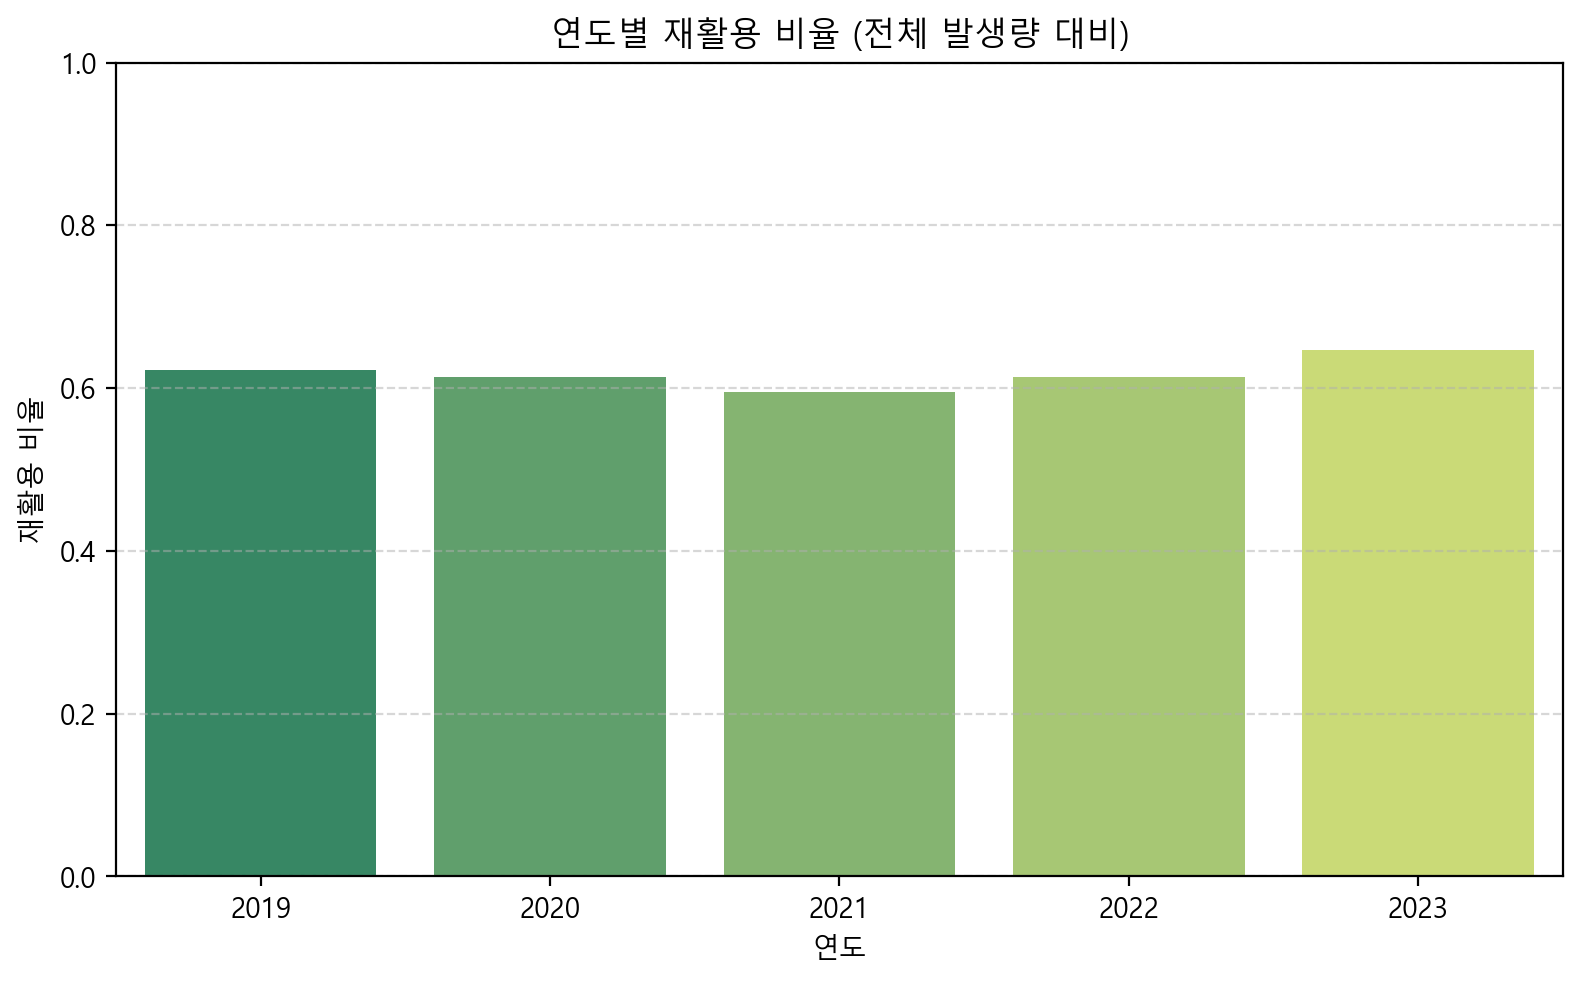

In [19]:
# 연도별 발생량 합계와 재활용량 합계 계산
yearly_summary = filtered_grouped.groupby('연도')[['발생량', '재활용']].sum().reset_index()

# 재활용 비율 계산
yearly_summary['재활용비율'] = yearly_summary['재활용'] / yearly_summary['발생량']

# 시각화
plt.figure(figsize=(8, 5))
sns.barplot(data=yearly_summary, x='연도', y='재활용비율', palette="summer")

plt.title('연도별 재활용 비율 (전체 발생량 대비)')
plt.ylabel('재활용 비율')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

In [33]:
yearly_summary

,연도,발생량,재활용,재활용비율
0,2019,7708727.0,4797341.0,0.622326
1,2020,8621457.0,5291423.8,0.613751
2,2021,8404277.9,5005391.4,0.595577
3,2022,11547665.7,7080009.2,0.613112
4,2023,11879205.1,7684869.2,0.646918


<br>

### 02-2. 부산지역만

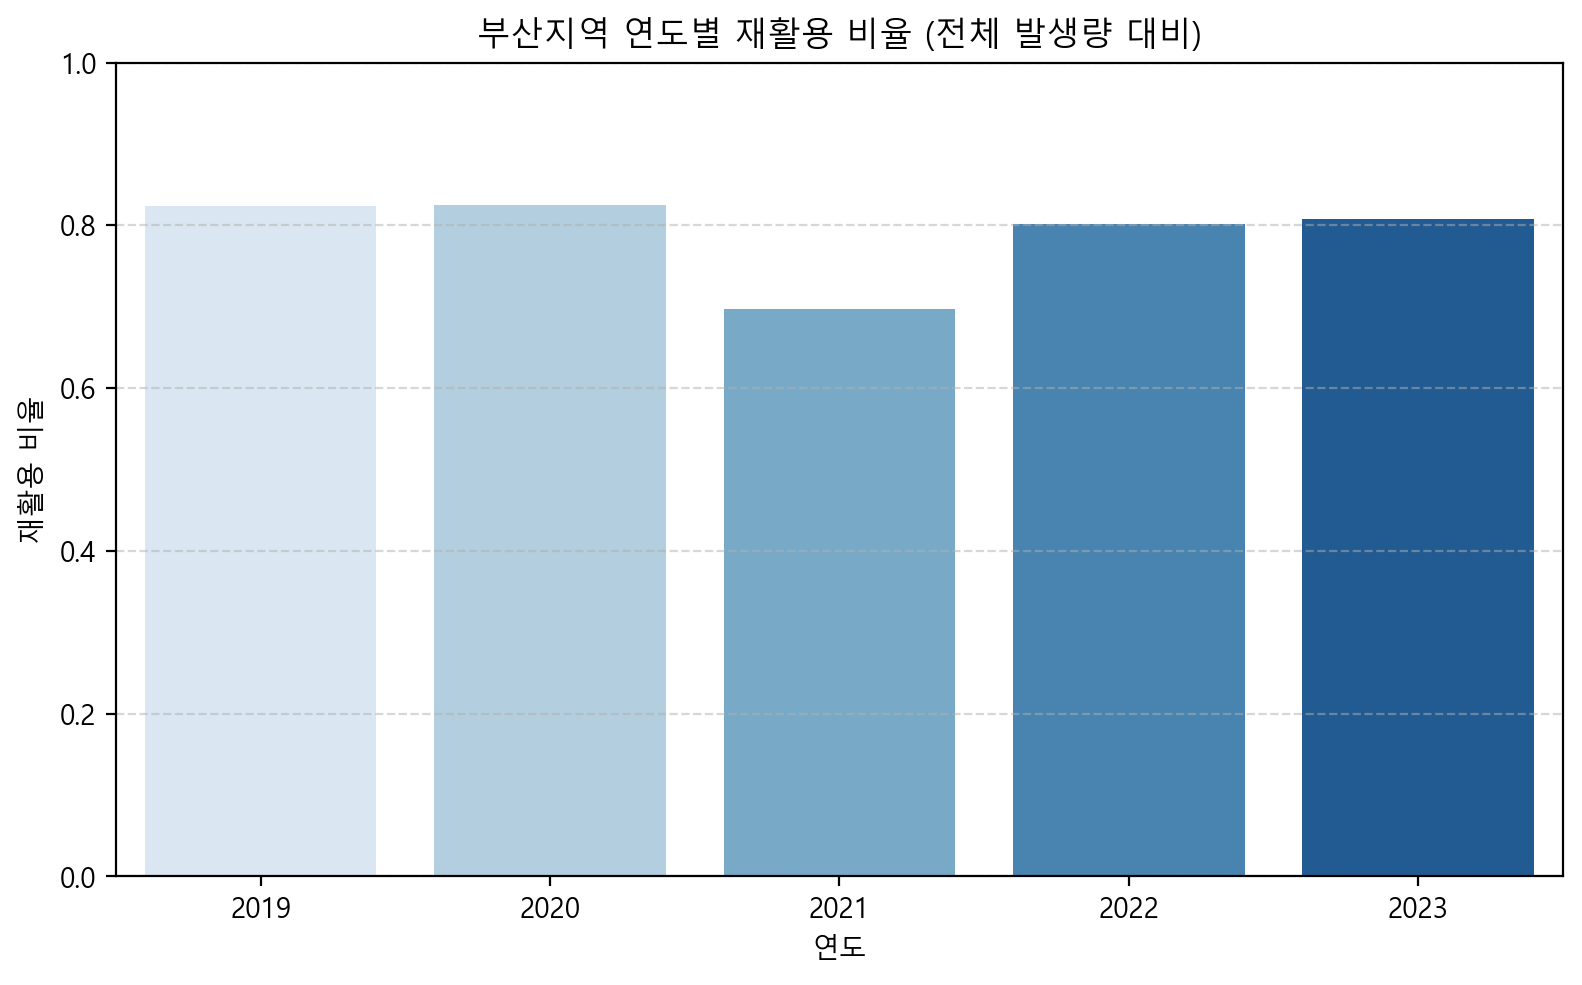

In [32]:
# 부산 지역 데이터만 필터링
busan_df = filtered_grouped[filtered_grouped['행정구역'].str.startswith('부산_')]

# 연도별 발생량/재활용 합계 계산
busan_summary = busan_df.groupby('연도')[['발생량', '재활용']].sum().reset_index()
busan_summary['재활용비율'] = busan_summary['재활용'] / busan_summary['발생량']

# 시각화
plt.figure(figsize=(8, 5))
sns.barplot(data=busan_summary, x='연도', y='재활용비율', palette="Blues")

plt.title('부산지역 연도별 재활용 비율 (전체 발생량 대비)')
plt.ylabel('재활용 비율')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

In [36]:
# 부산
busan_summary

,연도,발생량,재활용,재활용비율
0,2019,1077115.0,887242.0,0.823721
1,2020,1148394.2,947735.6,0.825270
2,2021,786487.3,548799.0,0.697785
3,2022,870833.7,698146.6,0.801699
4,2023,874276.3,705937.8,0.807454


### 종량제 중 재활용 처리되는 양은 큰 변화 없음 하지만 많다..! 80%나 됨

부산광역시 처리방식별 발생량 비중 (%):  재활용    79.63
소각     13.92
매립      6.44
기타      0.02
dtype: float64


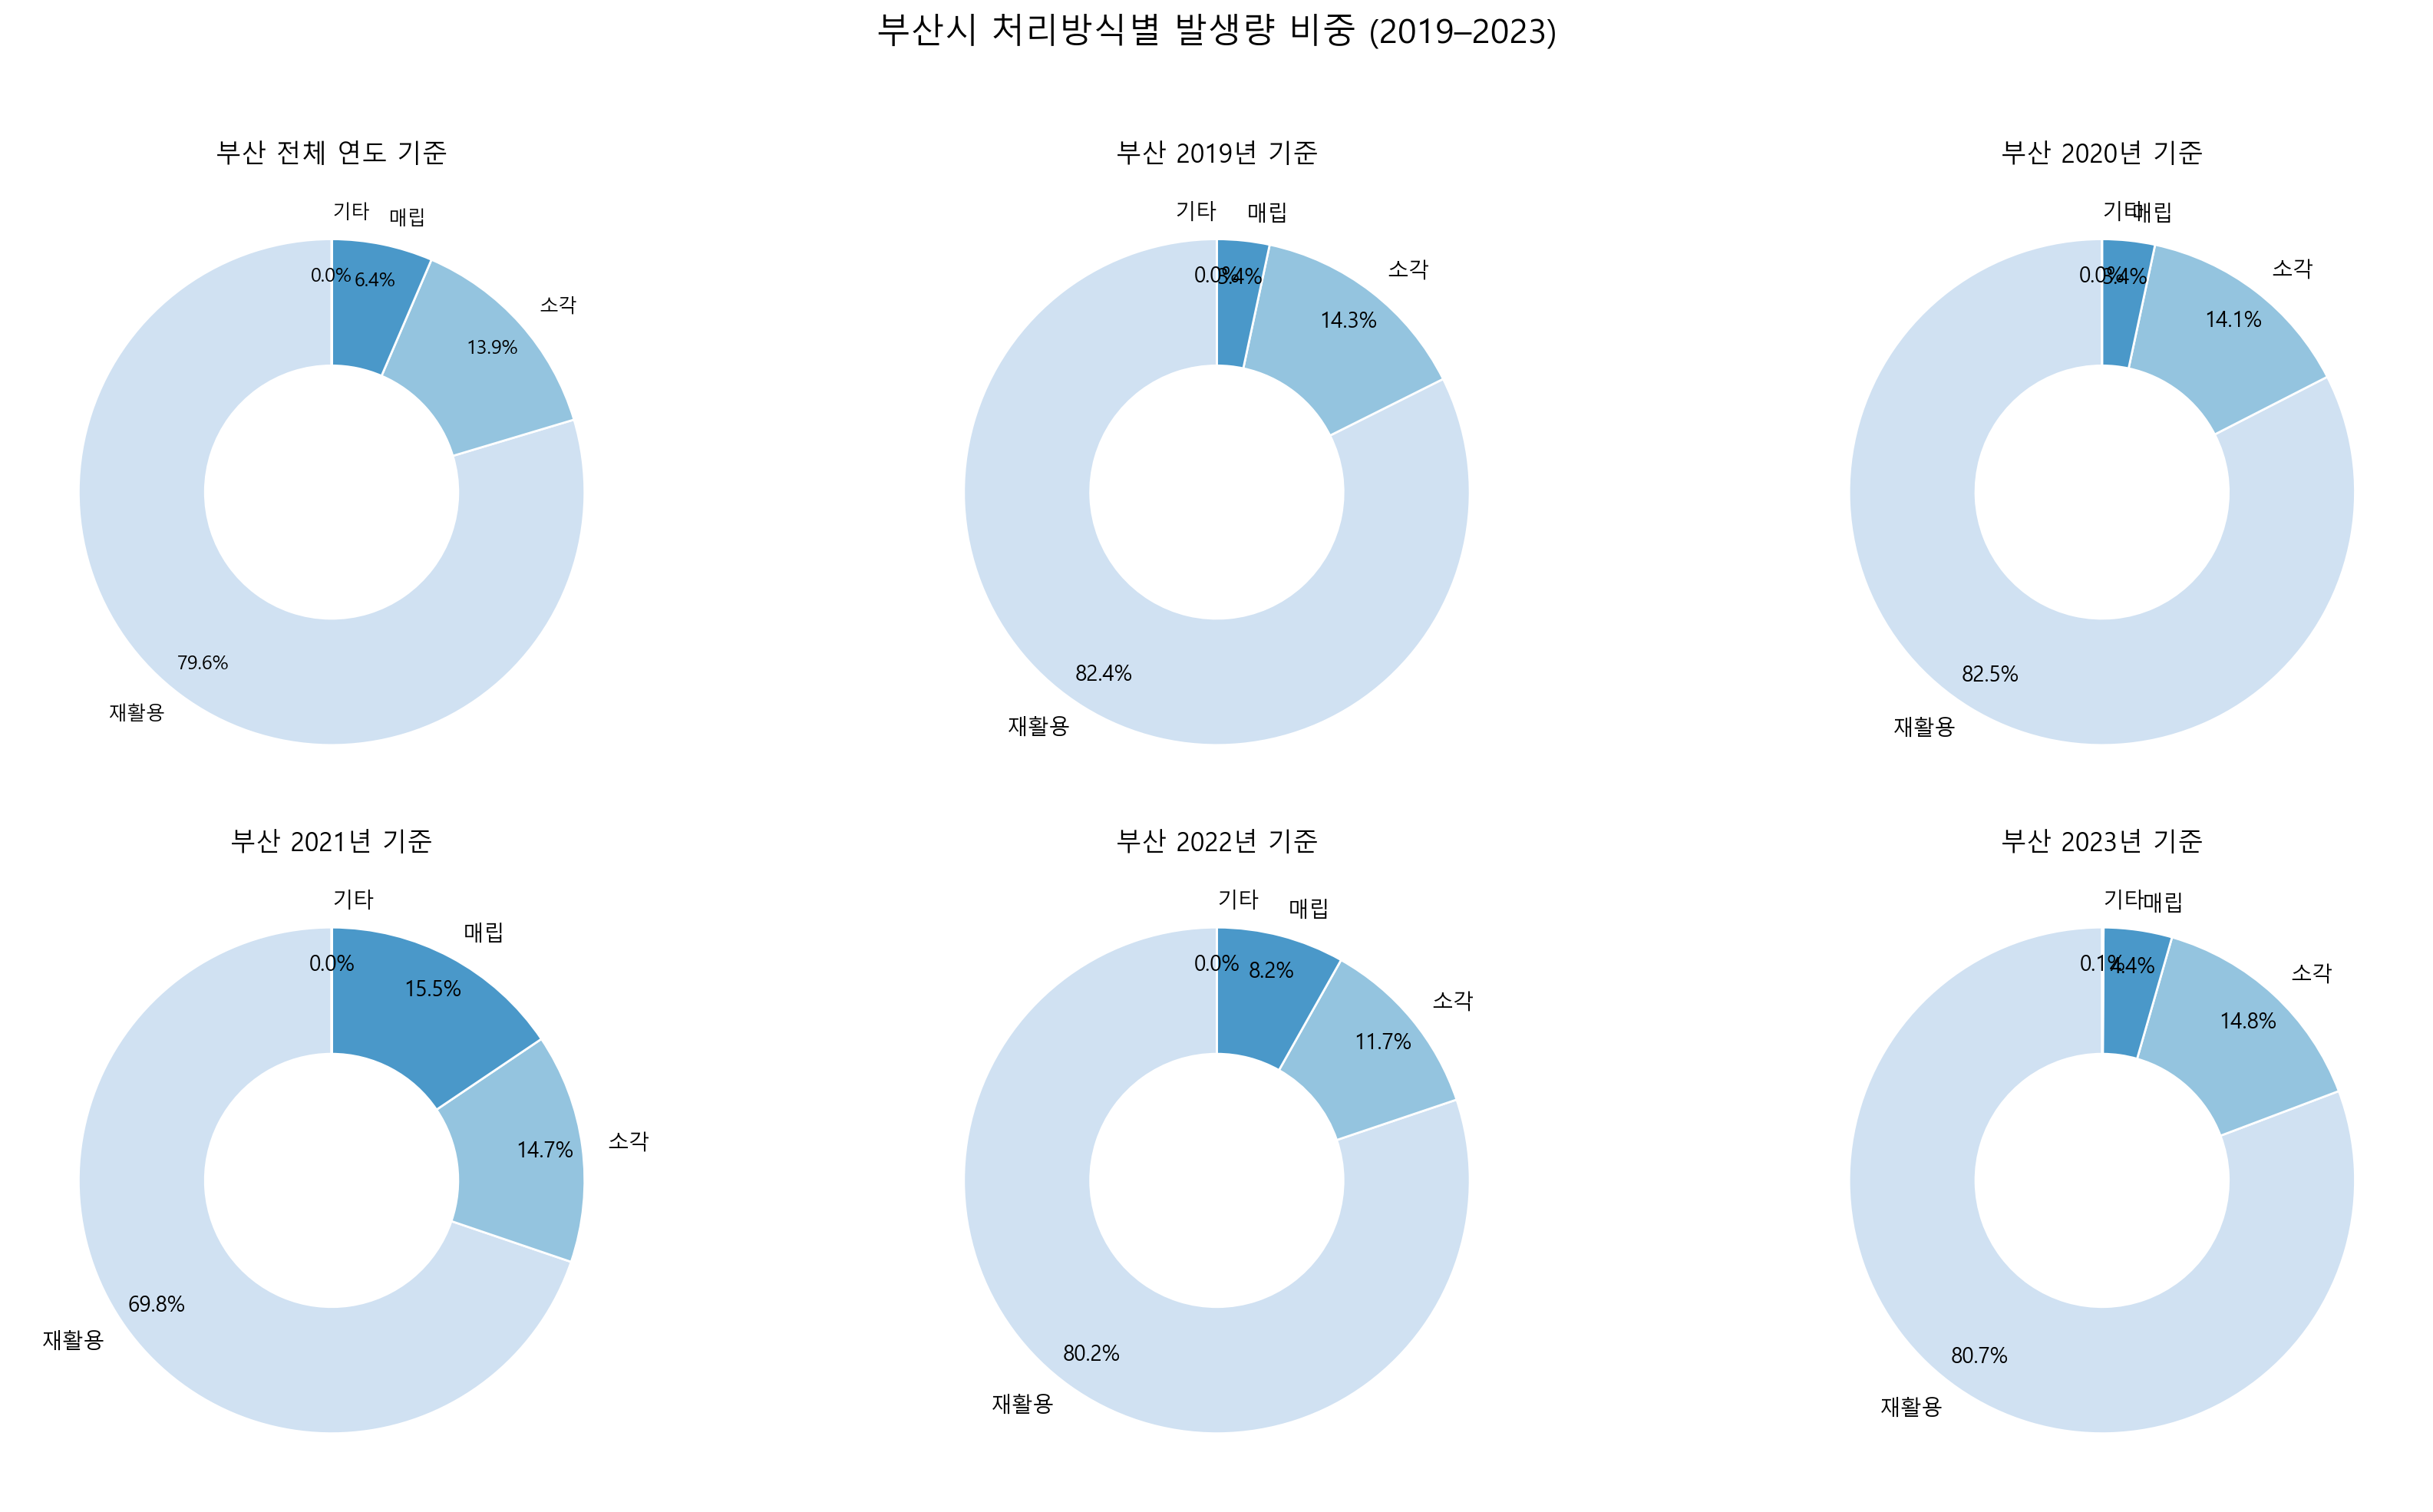

In [30]:
# 연도 목록 추출
years = sorted(busan_df['연도'].unique())

# 서브플롯 생성
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
axs = axs.flatten()

# 색상 팔레트 (처리 방식 수만큼)
palette_busan = sns.color_palette("Blues", 4)  # 재활용, 소각, 매립, 기타

# 0번째 subplot: 전체 연도 통합
total_amount = busan_df[['재활용', '소각', '매립', '기타']].sum().sum()
cat_amount = busan_df[['재활용', '소각', '매립', '기타']].sum()
cat_amount_pct = (cat_amount / total_amount * 100).round(2)
print("부산광역시 처리방식별 발생량 비중 (%): ", cat_amount_pct)

axs[0].pie(
    cat_amount_pct.values,
    labels=cat_amount_pct.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='w'),
    pctdistance=0.85,
    colors=palette_busan,
    textprops={'fontsize': 9}
)
axs[0].set_title("부산 전체 연도 기준")

# 연도별 pie chart
for i, year in enumerate(years):
    yearly_data = busan_df[busan_df["연도"] == year]
    yearly_total = yearly_data[['재활용', '소각', '매립', '기타']].sum().sum()
    yearly_cat = yearly_data[['재활용', '소각', '매립', '기타']].sum()
    yearly_cat_pct = (yearly_cat / yearly_total * 100).round(2)
#     print(f"부산광역시 {year}년 처리방식별 발생량 비중 (%): ", yearly_cat_pct)

    axs[i+1].pie(
        yearly_cat_pct.values,
        labels=yearly_cat_pct.index,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(width=0.5, edgecolor='w'),
        pctdistance=0.85,
        colors=palette_busan,
        textprops={'fontsize': 10}
    )
    axs[i+1].set_title(f"부산 {year}년 기준")

for ax in axs:
    ax.set_aspect("equal")

plt.suptitle("부산시 처리방식별 발생량 비중 (2019–2023)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

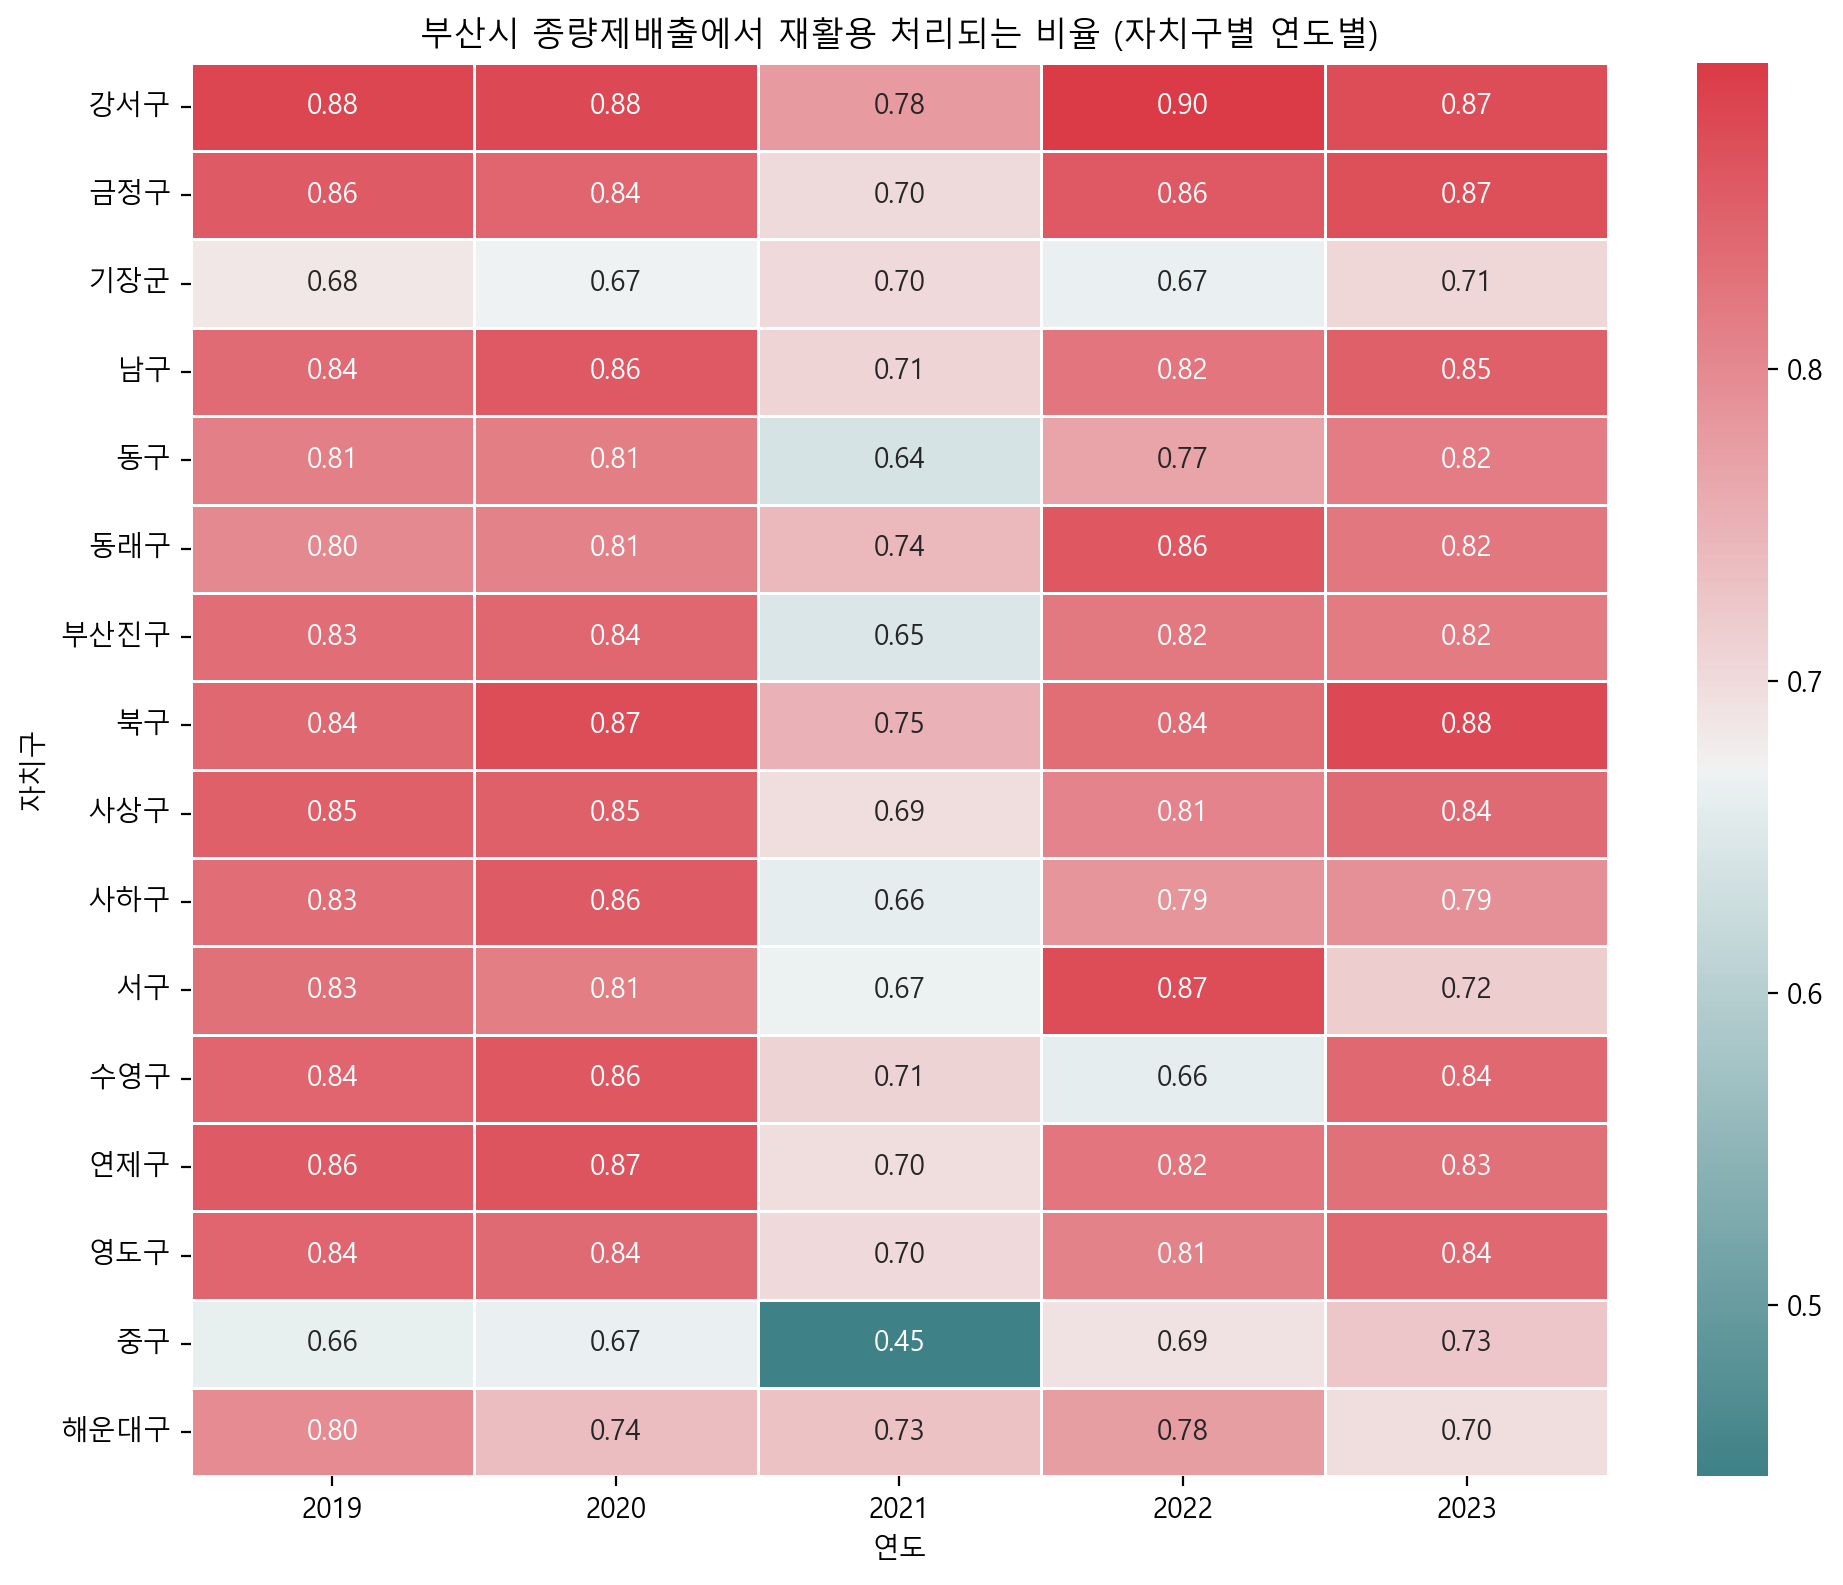

In [29]:
cmap = sns.diverging_palette(200, 10, as_cmap=True)

# 자치구만
busan_df['자치구'] = busan_df['행정구역'].str.replace('부산_', '', regex=False)

# 재활용 비율 계산
busan_df['재활용비율'] = busan_df['재활용'] / busan_df['발생량']

# 피벗 테이블 생성: 행 = 자치구, 열 = 연도, 값 = 재활용비율
pivot_table = busan_df.pivot(index='자치구', columns='연도', values='재활용비율')

# 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table,
            annot=True,
            fmt=".2f",
            cmap=cmap,
            linewidths=0.5)

plt.title('부산시 종량제배출에서 재활용 처리되는 비율 (자치구별 연도별)')
plt.xlabel('연도')
plt.ylabel('자치구')
plt.tight_layout()